In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import matplotlib.dates as mdates


plt.rcParams.update({
    'font.family'      : 'serif',
    'font.size'        : 9,
    'axes.titlesize'   : 10,
    'axes.titleweight' : 'bold',
    'axes.labelsize'   : 9,
    'xtick.labelsize'  : 8,
    'ytick.labelsize'  : 8,
    'legend.fontsize'  : 8,
    'figure.dpi'       : 150,
})

# 1. Load Data

In [2]:
df = pd.read_csv('../../output/processed_data/04_Regression_handled.csv')

print('Shape    :', df.shape)
print('Day range:', df['day'].min(), 'to', df['day'].max())
print('\nSector names in data:')
print(df['sector'].value_counts().to_string())

Shape    : (70413, 23)
Day range: -196 to 60

Sector names in data:
sector
Food & Beverage               11200
Diversified Financials        10112
Consumer Services              8293
Capital Goods                  7558
Materials                      5753
Banks                          4348
Real Estate                    4032
Retailing                      3443
Insurance                      3283
Utilities                      2297
Healthcare Equipment           2270
Consumer Durables              2045
Commercial Services            1603
Food Retailing                 1010
Energy                          767
Transportation                  727
Telecommunication Services      514
Others                          327
Household Products              317
Software & Services             257
Automobiles                     257


## 2. Filters

**Filter 1 — Thin trading:**  Remove stocks with trading days < 60 in estimate window

**Filter 2 — Extreme beta:**  Removed stocks with extreme beta values (outliers)

**Filter 3 — Micro-sectors:**  Removed sectors with stocks < 5

In [3]:
# ── Filter 1: Thin trading ────────────────────────────────────────────────────
est_window = df[(df['day'] >= -120) & (df['day'] <= -6)]

trading_days = (
    est_window.groupby('symbol')['day']
    .count()
    .reset_index()
    .rename(columns={'day': 'trading_days'})
)

sufficient    = trading_days[trading_days['trading_days'] >= 60]['symbol']
removed_thin  = trading_days[trading_days['trading_days'] <  60][['symbol', 'trading_days']]

print(f'Filter 1 — thin trading  : dropped {len(removed_thin)} stocks, kept {len(sufficient)}')
print('Removed stocks:')
print(removed_thin.sort_values('trading_days').to_string(index=False))

df = df[df['symbol'].isin(sufficient)].copy()

# ── Filter 2: Extreme beta ────────────────────────────────────────────────────
beta_per_stock = (
    df[(df['day'] >= -120) & (df['day'] <= -6)]
    .groupby('symbol')['beta']
    .first()
    .reset_index()
)

valid_beta    = beta_per_stock[
    (beta_per_stock['beta'] >= -3) &
    (beta_per_stock['beta'] <=  5)
]['symbol']
removed_beta  = beta_per_stock[
    (beta_per_stock['beta'] < -3) |
    (beta_per_stock['beta'] >  5)
][['symbol', 'beta']]

print(f'\nFilter 2 — extreme beta  : dropped {len(removed_beta)} stocks, kept {len(valid_beta)}')
print('Removed stocks:')
print(removed_beta.sort_values('beta', ascending=False).to_string(index=False))

df = df[df['symbol'].isin(valid_beta)].copy()

# ── Summary ───────────────────────────────────────────────────────────────────
print(f'\nTotal stocks before filters : {len(trading_days)}')
print(f'Removed — thin trading      : {len(removed_thin)}')
print(f'Removed — extreme beta      : {len(removed_beta)}')
print(f'Final qualifying stocks     : {len(valid_beta)}')

Filter 1 — thin trading  : dropped 5 stocks, kept 280
Removed stocks:
    symbol  trading_days
 JFP.N0000             2
MERC.N0000            20
 CSF.N0000            31
SWAD.N0000            34
AGST.X0000            51

Filter 2 — extreme beta  : dropped 1 stocks, kept 279
Removed stocks:
    symbol      beta
SEMB.X0000 -3.587677

Total stocks before filters : 285
Removed — thin trading      : 5
Removed — extreme beta      : 1
Final qualifying stocks     : 279


## 3. Compute Abnormal Return (AR)
`AR = R_i − (alpha + beta × R_m)`

In [4]:


"""df['AR'] = df['R_i'] - (df['alpha'] + df['beta'] * df['R_m'])

# Sanity check — mean AR in estimation window should be ≈ 0
mean_ar = df[(df['day'] >= -120) & (df['day'] <= -6)]['AR'].mean()
print(f'Mean AR in estimation window: {mean_ar:.6f}')

est_df   = df[(df['day'] >= -120) & (df['day'] <= -6)].copy()
event_df = df[(df['day'] >= -5)   & (df['day'] <= 30)].copy()"""

"df['AR'] = df['R_i'] - (df['alpha'] + df['beta'] * df['R_m'])\n\n# Sanity check — mean AR in estimation window should be ≈ 0\nmean_ar = df[(df['day'] >= -120) & (df['day'] <= -6)]['AR'].mean()\nprint(f'Mean AR in estimation window: {mean_ar:.6f}')\n\nest_df   = df[(df['day'] >= -120) & (df['day'] <= -6)].copy()\nevent_df = df[(df['day'] >= -5)   & (df['day'] <= 30)].copy()"

Drop stocks with NaN alpha/beta before computing AR 

In [5]:
# Drop any stocks that have no alpha/beta (failed the min-30-obs regression filter).
# These stocks were never assigned parameters so AR would be NaN for their
# entire event window. Remove them here before computing AR.
no_params = df['alpha'].isna() | df['beta'].isna()
dropped_no_params = df[no_params]['symbol'].unique()
if len(dropped_no_params) > 0:
    print(f'Dropping {len(dropped_no_params)} stocks with no regression params: '
          f'{list(dropped_no_params)}')
    df = df[~no_params].copy()

df['AR'] = df['R_i'] - (df['alpha'] + df['beta'] * df['R_m'])

# Sanity check — mean AR in estimation window should be ≈ 0
mean_ar = df[(df['day'] >= -120) & (df['day'] <= -6)]['AR'].mean()
print(f'Mean AR in estimation window: {mean_ar:.6f}  (should be ≈ 0)')

est_df   = df[(df['day'] >= -120) & (df['day'] <= -6)].copy()
event_df = df[(df['day'] >= -5)   & (df['day'] <= 30)].copy()

Mean AR in estimation window: 0.000000  (should be ≈ 0)


## 4. Compute CAR per Stock over the Event Window

In [6]:
# ── CAR anchored at Day 0 ─────────────────────────────────────────────────────
# Post-event (day >= 0): cumsum forward from Day 0
# Pre-event  (day <  0): cumsum backwards to Day 0 (negated)

def compute_anchored_car(group):
    group = group.sort_values('day').copy()

    post = group[group['day'] >= 0].copy()
    post['CAR_anchored'] = post['AR'].cumsum()

    pre = group[group['day'] < 0].sort_values('day', ascending=False).copy()
    pre['CAR_anchored'] = -pre['AR'].cumsum()
    pre = pre.sort_values('day')

    return pd.concat([pre, post]).sort_values('day')

#bug -looses symbol
#event_df = event_df.groupby('symbol', group_keys=False).apply(compute_anchored_car)

#event_df['CAR_pct'] = event_df['CAR_anchored'] * 100

# Sanity check — Day 0 CAR should equal AR(Day 0) for every stock
#day0 = event_df[event_df['day'] == 0]
#match = (day0['CAR_anchored'].round(8) == day0['AR'].round(8)).all()
#print(f'Day 0 sanity check passed: {match}')
#print(f'Mean AR in event window  : {event_df["AR"].mean():.6f}')

#---------------------------------------------------- fix

# Process each stock individually — symbol column is preserved naturally
pieces = []
for sym, grp in event_df.groupby('symbol'):
    pieces.append(compute_anchored_car(grp))

event_df = pd.concat(pieces).reset_index(drop=True)
event_df['CAR_pct'] = event_df['CAR_anchored'] * 100

# ── Sanity check — Day 0 CAR must equal AR(Day 0) for every stock ─────────────
day0    = event_df[event_df['day'] == 0]
failing = day0[day0['CAR_anchored'].round(8) != day0['AR'].round(8)]

if len(failing) > 0:
    print(f'Day 0 sanity check FAILED for {len(failing)} stocks:')
    print(failing[['symbol', 'day', 'AR', 'CAR_anchored']].to_string())
    raise ValueError(
        f'Day 0 CAR != AR for {len(failing)} stocks. '
        f'Check compute_anchored_car() or the AR calculation above.'
    )

print(f'✓ Day 0 sanity check passed for all {len(day0)} stocks')
print(f'  Mean AR in event window: {event_df["AR"].mean():.6f}')



✓ Day 0 sanity check passed for all 273 stocks
  Mean AR in event window: -0.001666


## 5. Aggregate Mean CAR by Sector and Day

In [7]:
sector_car = (
    event_df
    .groupby(['sector', 'day'])['CAR_pct']
    .mean()
    .reset_index()
    .rename(columns={'CAR_pct': 'mean_CAR_pct'})
)

print('Mean CAR on Day 0 by sector (cleaned):')
print(
    sector_car[sector_car['day'] == 0]
    .sort_values('mean_CAR_pct')
    .to_string(index=False)
)

Mean CAR on Day 0 by sector (cleaned):
                    sector  day  mean_CAR_pct
       Commercial Services    0     -2.349391
                    Others    0     -2.273680
                    Energy    0     -1.164222
            Transportation    0     -1.042866
                 Insurance    0     -1.006885
                 Utilities    0     -0.936934
         Consumer Services    0     -0.417652
      Healthcare Equipment    0     -0.335161
               Real Estate    0     -0.316486
    Diversified Financials    0     -0.243055
                 Materials    0     -0.226441
         Consumer Durables    0     -0.161133
        Household Products    0     -0.120528
               Automobiles    0     -0.059426
                     Banks    0     -0.016412
             Capital Goods    0      0.044595
           Food & Beverage    0      0.152533
       Software & Services    0      0.172953
Telecommunication Services    0      0.565565
            Food Retailing    0      1.07

In [8]:
market_car = {}

windows = {
    'CAR(-5,-1)' : (-5, -1),
    'CAR(0,0)'   : ( 0,  0),
    'CAR(0,+5)'  : ( 0,  5),
    'CAR(-5,+30)': (-5, 30),
}


for label, (t1, t2) in windows.items():
    window_data = event_df[(event_df['day'] >= t1) & (event_df['day'] <= t2)]
    stock_car = window_data.groupby('symbol')['AR'].sum() * 100
    market_car[label] = {
        'mean'   : round(stock_car.mean(), 3),
        'std'    : round(stock_car.std(), 3),
        'n'      : len(stock_car)
    }

market_df = pd.DataFrame(market_car).T
print('Market-level CAR summary:')
print(market_df.to_string())

Market-level CAR summary:
              mean     std      n
CAR(-5,-1)  -1.014   5.732  279.0
CAR(0,0)    -0.162   2.639  273.0
CAR(0,+5)   -2.407   7.230  279.0
CAR(-5,+30) -5.859  23.970  279.0


## Figure 0 — ASPI Index Trajectory
Daily ASPI close from Feb 2025 to Feb 2026 with landfall marker at Day 0.

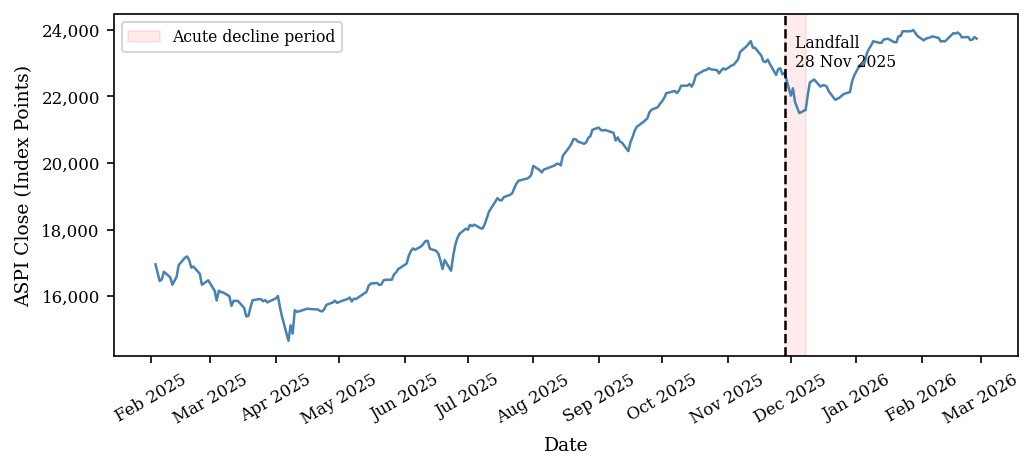

In [9]:
# ── ASPI trajectory: one row per trading date ────────────────────────────────
aspi_daily = (
    df[['date', 'day', 'aspi_close']]
    .drop_duplicates(subset='date')
    .sort_values('date')
    .reset_index(drop=True)
)

# Identify Day 0 date (landfall)
landfall_date = aspi_daily.loc[aspi_daily['day'] == 0, 'date'].values
if len(landfall_date) == 0:
    landfall_date = aspi_daily.loc[(aspi_daily['day'] - 0).abs().idxmin(), 'date']
else:
    landfall_date = landfall_date[0]

aspi_daily['date_dt'] = pd.to_datetime(aspi_daily['date'])
landfall_dt = pd.to_datetime(landfall_date)

fig0, ax0 = plt.subplots(figsize=(7, 3.2))

ax0.plot(
    aspi_daily['date_dt'],
    aspi_daily['aspi_close'],
    color='steelblue',
    linewidth=1.2,
    zorder=2
)

ax0.axvline(
    x=landfall_dt,
    color='black',
    linewidth=1.2,
    linestyle='--',
    zorder=3
)
ax0.text(
    landfall_dt,
    aspi_daily['aspi_close'].max() * 0.995,
    '  Landfall\n  28 Nov 2025',
    fontsize=7.5,
    va='top',
    color='black'
)

trough_date = aspi_daily.loc[(aspi_daily['day'] - 5).abs().idxmin(), 'date_dt']
ax0.axvspan(
    landfall_dt, trough_date,
    alpha=0.08, color='red', zorder=1,
    label='Acute decline period'
)

ax0.set_xlabel('Date')
ax0.set_ylabel('ASPI Close (Index Points)')

ax0.xaxis.set_major_locator(mdates.MonthLocator())
ax0.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax0.tick_params(axis='x', rotation=30)

ax0.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

ax0.legend(fontsize=7.5, loc='upper left')
plt.tight_layout()
fig0.savefig('../../output/figs/figure_aspi.pdf', bbox_inches='tight')
plt.show()


## Figure 1 — Sector CAR over the Event Window

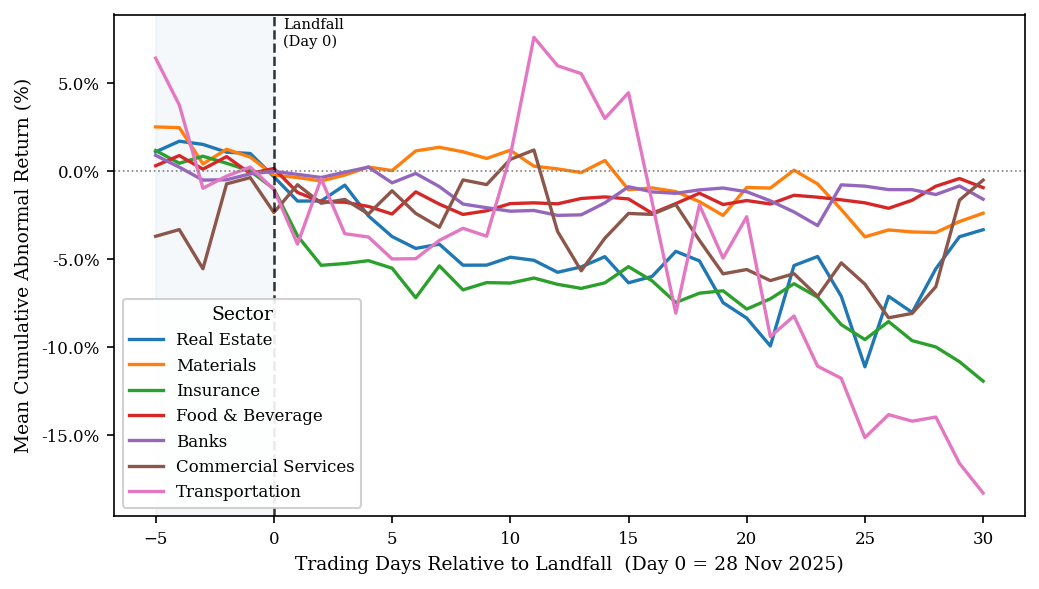

In [10]:
sectors = [
    'Real Estate',
    'Materials',
    'Insurance',
    'Food & Beverage',
    'Banks',
    'Commercial Services',
    'Transportation'
]

sector_car_plot = sector_car[sector_car['sector'].isin(sectors)].copy()
palette = sns.color_palette('tab10', n_colors=len(sectors))
col_map = dict(zip(sectors, palette))

fig1, ax1 = plt.subplots(figsize=(7, 4))

for sector in sectors:
    data = sector_car_plot[sector_car_plot['sector'] == sector].sort_values('day')
    ax1.plot(
        data['day'],
        data['mean_CAR_pct'],
        label=sector,
        color=col_map[sector],
        linewidth=1.6
    )

# Landfall marker
ax1.axvline(x=0, color='black', linewidth=1.2, linestyle='--', alpha=0.8)
ax1.text(0.4, ax1.get_ylim()[1] * 0.98,
         'Landfall\n(Day 0)', fontsize=7, color='black', va='top')

# Zero baseline
ax1.axhline(y=0, color='grey', linewidth=0.8, linestyle=':')

# Shade anticipation period
ax1.axvspan(-5, 0, alpha=0.05, color='steelblue')

ax1.set_xlabel('Trading Days Relative to Landfall  (Day 0 = 28 Nov 2025)')
ax1.set_ylabel('Mean Cumulative Abnormal Return (%)')
ax1.xaxis.set_major_locator(mticker.MultipleLocator(5))
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
ax1.legend(title='Sector', loc='lower left', framealpha=0.9)

plt.tight_layout()
fig1.savefig('../../output/figs/figure1_sector_CAR.pdf', bbox_inches='tight')
plt.show()

## Figure 2 — Pre-Event Beta Distribution by Sector
Outliers beyond β ∈ [−3, 5] removed (thin-trading artefacts).

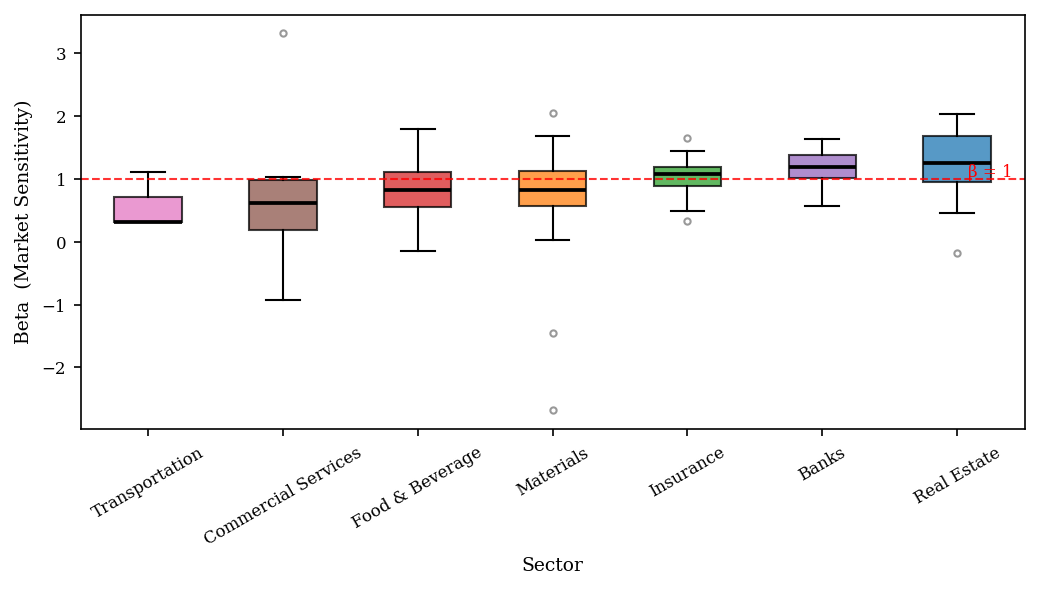

In [11]:
beta_per_stock = (
    est_df
    .groupby(['symbol', 'sector'])['beta']
    .first()
    .reset_index()
)

df_plot = beta_per_stock[beta_per_stock['sector'].isin(sectors)].copy()

# Sort by median beta low → high
sector_order = (
    df_plot.groupby('sector')['beta']
    .median()
    .sort_values()
    .index.tolist()
)

palette2 = [col_map[s] for s in sector_order]

fig2, ax2 = plt.subplots(figsize=(7, 4))

bp = ax2.boxplot(
    [df_plot[df_plot['sector'] == s]['beta'].values for s in sector_order],
    tick_labels=sector_order,
    patch_artist=True,
    medianprops=dict(color='black', linewidth=1.8),
    flierprops=dict(marker='o', markersize=3, alpha=0.4, linestyle='none'),
    whiskerprops=dict(linewidth=1),
    capprops=dict(linewidth=1),
)

for patch, colour in zip(bp['boxes'], palette2):
    patch.set_facecolor(colour)
    patch.set_alpha(0.75)

ax2.axhline(y=1, color='red', linewidth=1, linestyle='--', alpha=0.8)
ax2.text(len(sector_order) + 0.08, 1.03, 'β = 1', fontsize=8, color='red')

ax2.set_xlabel('Sector')
ax2.set_ylabel('Beta  (Market Sensitivity)')
ax2.tick_params(axis='x', rotation=30)

plt.tight_layout()
fig2.savefig('../../output/figs/figure2_beta_by_sector.pdf', bbox_inches='tight')
plt.show()

In [12]:
rows = []
for sector in sorted(event_df['sector'].unique()):
    sec_df = event_df[event_df['sector'] == sector]
    row = {'Sector': sector}
    for label, (t1, t2) in windows.items():
        window_data = sec_df[
            (sec_df['day'] >= t1) &
            (sec_df['day'] <= t2)
        ]
        stock_car = window_data.groupby('symbol')['AR'].sum() * 100
        row[label] = round(stock_car.mean(), 2)
    rows.append(row)

car_table = pd.DataFrame(rows).set_index('Sector')

print('CAR Summary Table (mean % per sector):')
print(car_table.to_string())

car_table.to_csv('../../output/tables/car_summary_table.csv')

CAR Summary Table (mean % per sector):
                            CAR(-5,-1)  CAR(0,0)  CAR(0,+5)  CAR(-5,+30)
Sector                                                                  
Automobiles                       1.40     -0.06      -0.88        -0.11
Banks                            -0.43     -0.02      -0.60        -2.02
Capital Goods                    -0.83      0.04       1.99         0.28
Commercial Services               3.70     -2.35      -3.87         3.19
Consumer Durables                -2.06     -0.16      -1.94        -3.07
Consumer Services                 0.52     -0.42      -4.43       -10.19
Diversified Financials           -1.45     -0.24      -4.10        -9.55
Energy                           -6.19     -1.16      -9.48       -17.93
Food & Beverage                  -0.33      0.15      -2.61        -1.27
Food Retailing                    0.21      1.07       1.67        -3.15
Healthcare Equipment             -0.11     -0.34       1.77         0.84
Household Pr

####  Per-stock CAR summary table 


In [13]:
# One row per qualifying stock showing CAR across all four event windows.
# This is the core output table sector averages are derived from these values.

rows = []
for sym, grp in event_df.groupby('symbol'):
    sector = grp['sector'].iloc[0]
    # Also pull alpha, beta, n_obs from the stock's estimation window data
    est_grp = est_df[est_df['symbol'] == sym]
    alpha   = est_grp['alpha'].iloc[0] if len(est_grp) > 0 else np.nan
    beta    = est_grp['beta'].iloc[0]  if len(est_grp) > 0 else np.nan
    n_obs   = len(est_grp.dropna(subset=['R_i', 'R_m']))

    row = {
        'symbol'     : sym,
        'sector'     : sector,
        'alpha'      : round(alpha, 6),
        'beta'       : round(beta, 4),
        'n_obs'      : n_obs,
    }
    for label, (t1, t2) in windows.items():
        window_data  = grp[(grp['day'] >= t1) & (grp['day'] <= t2)]
        row[label]   = round(window_data['AR'].sum() * 100, 4)
    rows.append(row)

per_stock_car = (
    pd.DataFrame(rows)
    .sort_values(['sector', 'CAR(-5,+30)'])
    .reset_index(drop=True)
)

print(f'Per-stock CAR table: {len(per_stock_car)} stocks across '
      f'{per_stock_car["sector"].nunique()} sectors')
print()
print('Within-sector dispersion (std of CAR(-5,+30)):')
print(
    per_stock_car.groupby('sector')['CAR(-5,+30)']
    .agg(['mean','std','min','max','count'])
    .round(2)
    .sort_values('mean')
    .to_string()
)

per_stock_car.to_csv('../../output/tables/per_stock_car.csv', index=False)
print()
print(f'✓ Saved per_stock_car.csv — {len(per_stock_car)} rows')

Per-stock CAR table: 279 stocks across 21 sectors

Within-sector dispersion (std of CAR(-5,+30)):
                             mean    std     min    max  count
sector                                                        
Transportation             -24.69  25.29  -53.88  -9.34      3
Energy                     -17.93  26.16  -37.94  11.67      3
Retailing                  -16.58  79.63 -275.41  60.40     14
Insurance                  -13.09  10.22  -32.72   4.41     13
Others                     -13.08    NaN  -13.08 -13.08      1
Utilities                  -11.67  12.96  -27.96   7.65      9
Consumer Services          -10.19   8.57  -28.98   2.48     33
Diversified Financials      -9.55  13.45  -44.16  15.28     39
Materials                   -4.90  33.40 -130.28  39.54     22
Real Estate                 -4.69  16.38  -34.57  22.36     17
Household Products          -4.36    NaN   -4.36  -4.36      1
Food Retailing              -3.15  11.88  -16.05  12.33      4
Consumer Durables   

In [14]:
df.to_csv('../../output/processed_data/05_filtered.csv', index=False)
print(f'✓ Saved 05_filtered.csv — {df["symbol"].nunique()} symbols, {len(df):,} rows')

✓ Saved 05_filtered.csv — 279 symbols, 69,669 rows
